# Academic Analysis: High-Fidelity Data Structure Benchmarking
### Comprehensive Evaluation of 16 Data Structures ($10^3 \to 10^8$)

This notebook analyzes the performance of 16 data structures using a high-density, standardized traversal-only dataset. 
Metric units are normalized to cycles/instructions per element.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Modern GitHub Dark Aesthetics ---
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22', 
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e', 
    'text.color': '#e6edf3', 'grid.color': '#21262d',
    'font.family': 'sans-serif', 'axes.titlesize': 16,
    'legend.frameon': True, 'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d'
})

COLORS = {
    'Vector': '#79c0ff', 'Array': '#1f6feb', 'Deque': '#a5d6ff', 'Sequential': '#79c0ff',
    'BST': '#ff7b72', 'RBTree': '#ff9e44', 'BTree': '#f0883e', 'SkipList': '#d2a8ff', 'vEBTree': '#bc8cff',
    'LinkedList': '#f78166', 'SlabList': '#ffa198', 'Heap': '#58a6ff',
    'AoS': '#3fb950', 'SoA': '#56d364',
    'HashMap': '#e3b341', 'Trie': '#f8e3a1', 'CircularBuffer': '#388bfd'
}

def get_palette(structures):
    return [COLORS.get(s, '#8b949e') for s in structures]

In [9]:
def load_data(path):
    print(f"Loading {path}...")
    df = pd.read_csv(path)
    
    # Feature Engineering
    df['cycles_per_elem'] = df['median_cycles'] / df['N']
    df['ins_per_elem'] = df['median_instructions'] / df['N']
    if 'median_cycles' in df.columns and 'median_instructions' in df.columns:
        df['IPC'] = df['median_instructions'] / df['median_cycles']
    if 'median_cache_misses' in df.columns:
        df['cache_miss_rate'] = df['median_cache_misses'] / df['N']
    if 'median_branches' in df.columns and 'median_branch_misses' in df.columns:
        df['branch_mispred_rate'] = df['median_branch_misses'] / df['median_branches']
    
    # Filter noise and high variance
    df = df[df['N'] >= 1000]
    df = df[df['cv_pct'] < 15]
    return df

df = load_data("masterresultsOvernight.csv")
df.head()

Loading masterresultsOvernight.csv...


,data_structure,N,runs,median_cycles,median_instructions,ipc,median_cache_misses,median_branches,median_branch_misses,median_l1_misses,median_tlb_misses,cv_pct,stddev_cycles,ci95_cycles,cycles_per_elem,ins_per_elem,IPC,cache_miss_rate,branch_mispred_rate
5295,Trie,19057,1000,10614025,2830375,0.27,350347,811365,155246,166557,14246,14.4,1578615,97844,556.962009,148.521541,0.266664,18.384163,0.191339
5379,Trie,20657,1000,9535561,3062519,0.32,472999,876810,186214,157717,15647,13.7,1310315,81214,461.614029,148.255749,0.321168,22.897759,0.212377
5402,Trie,21203,1000,11244358,3150413,0.28,478162,901145,172696,186011,13949,14.5,1620884,100463,530.319200,148.583361,0.280177,22.551620,0.191641
5423,Trie,21269,1000,9852677,3163781,0.32,472109,907683,161352,187132,16840,12.1,1193220,73957,463.241196,148.750811,0.321109,22.197047,0.177763
5438,Trie,21568,1000,10140365,3220648,0.32,407835,926007,197450,191199,16855,11.1,1122725,69587,470.157873,149.325297,0.317607,18.909264,0.213227


## Figure 1 · Global Scaling: Normalized Cycles vs N
This plot identifies algorithmic efficiency across five orders of magnitude. Pointer-based structures exhibit the expected $O(\log N)$ or $O(N)$ memory-latency growth.

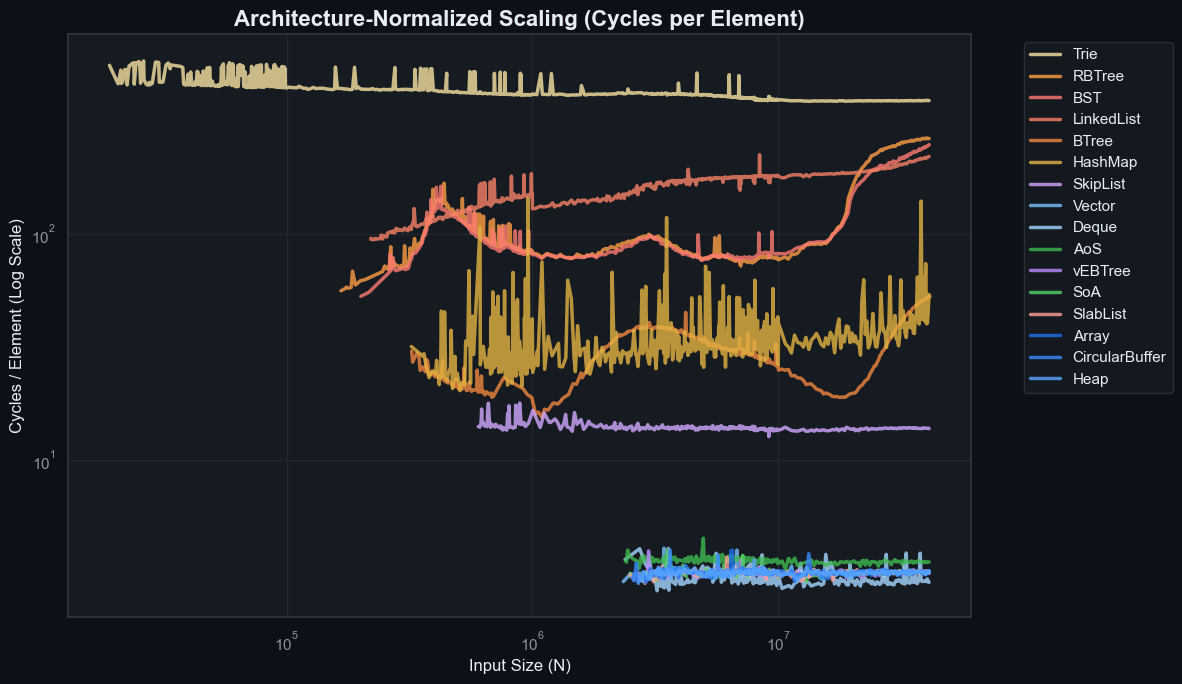

In [10]:
plt.figure(figsize=(12, 7))
structures = df['data_structure'].unique()
palette = get_palette(structures)
sns.lineplot(data=df, x='N', y='cycles_per_elem', hue='data_structure', palette=palette, lw=2.5, alpha=0.8)
plt.xscale('log')
plt.yscale('log')
plt.title("Architecture-Normalized Scaling (Cycles per Element)", fontweight='bold')
plt.xlabel("Input Size (N)")
plt.ylabel("Cycles / Element (Log Scale)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Figure 2 · Pipeline Efficiency (IPC Heatmap)
Visualizes how deeply each data structure utilizes the CPU's execution pipeline.

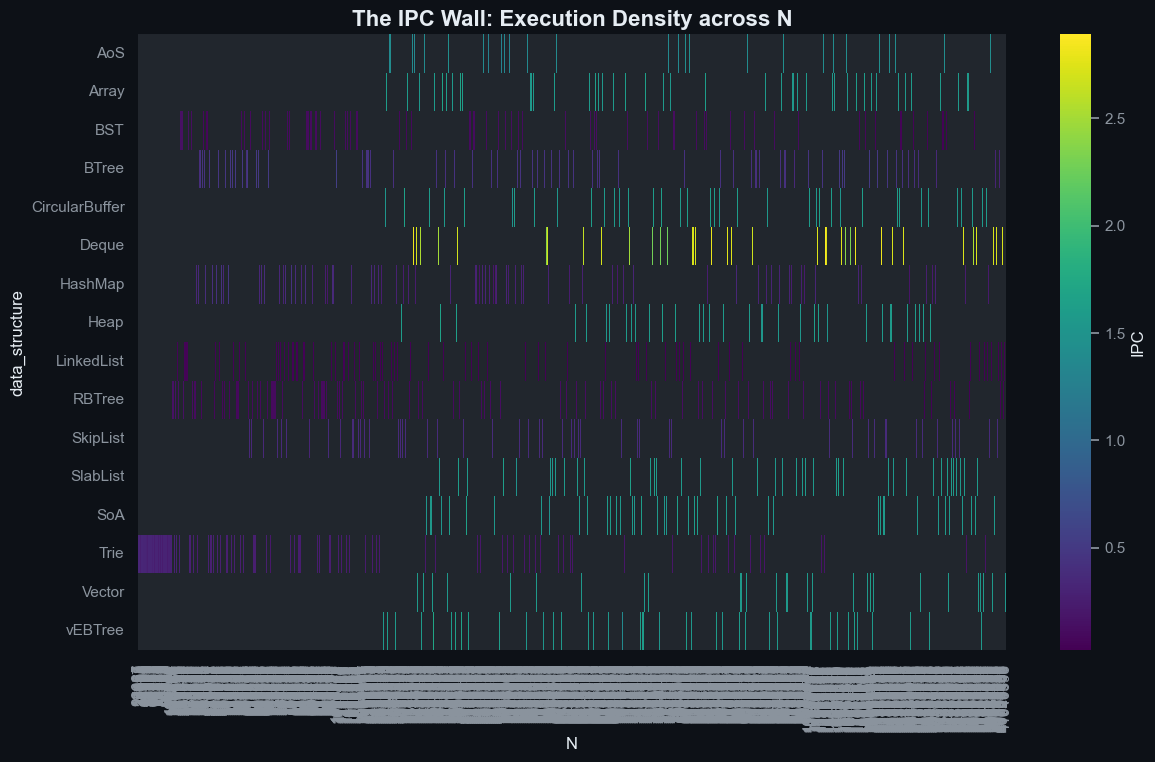

In [11]:
pivot_ipc = df.pivot_table(index='data_structure', columns='N', values='IPC', aggfunc='mean')
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_ipc, cmap='viridis', cbar_kws={'label': 'IPC'}, xticklabels=5)
plt.title("The IPC Wall: Execution Density across N", fontweight='bold')
plt.show()

## Figure 3 · Memory Hierarchy Transition Boundaries
Identifying L1/L2/L3 cache exhaustion points via Cache Misses per Element.

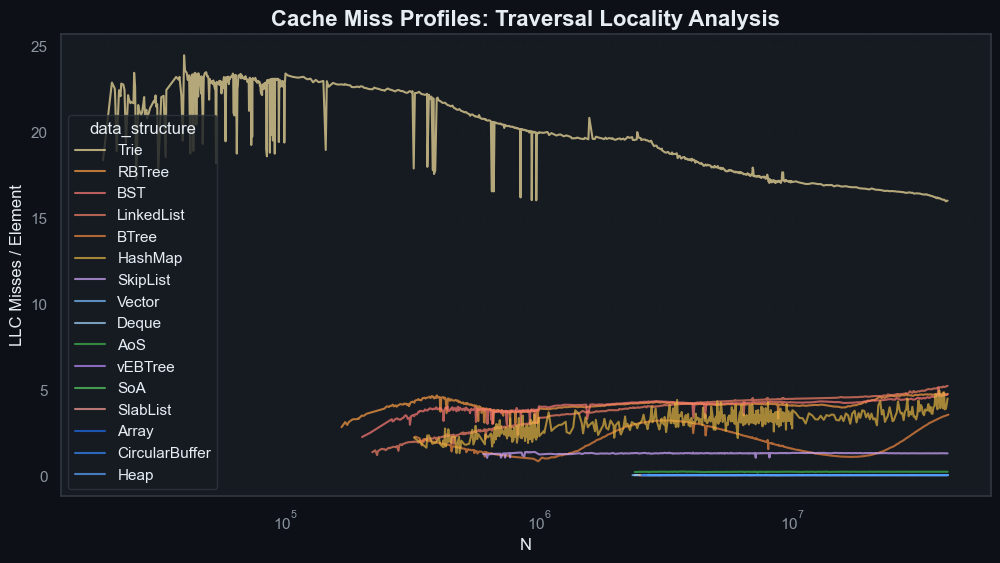

In [12]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='N', y='cache_miss_rate', hue='data_structure', palette=get_palette(df['data_structure'].unique()), alpha=0.7)
plt.xscale('log')
plt.title("Cache Miss Profiles: Traversal Locality Analysis", fontweight='bold')
plt.ylabel("LLC Misses / Element")
plt.grid(True, which="both", ls="--", alpha=0.2)
plt.show()

## Statistical Summary
Detailed efficiency ranking at high working set sizes.

In [13]:
summary = df.groupby('data_structure')[['cycles_per_elem', 'IPC', 'cache_miss_rate']].mean()
summary.sort_values(by='cycles_per_elem').style.background_gradient(cmap='RdYlGn_r')

,cycles_per_elem,IPC,cache_miss_rate
data_structure,,,
Deque,2.985988,2.638288,0.071381
Heap,3.166761,1.576029,0.070721
SlabList,3.167804,1.575632,0.070917
SoA,3.174143,1.570494,0.070726
vEBTree,3.174619,1.571118,0.070857
Array,3.174859,1.571191,0.070778
Vector,3.174962,1.569483,0.070521
CircularBuffer,3.184756,1.565933,0.070730
AoS,3.588843,1.389674,0.260833
